# Vocab length distribution

Load the TinyStories-valid BPE tokenizer and plot the distribution of token byte lengths.

In [1]:
import pickle
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

TOKENIZER_PATH = Path(
    "/Users/dohunlee/Documents/001_Projects/011_Stanford_CS336/assignment1-basics/artifacts/tokenizers/TinyStoriesValid_tokenizer.pkl"
)

with TOKENIZER_PATH.open("rb") as f:
    tokenizer = pickle.load(f)

vocab = tokenizer["vocab"]
print(f"Loaded {len(vocab):,} tokens from {TOKENIZER_PATH.name}")

Matplotlib is building the font cache; this may take a moment.


Loaded 10,000 tokens from TinyStoriesValid_tokenizer.pkl


min=1, max=15, mean=5.76
{1: 256, 2: 358, 3: 926, 4: 1484, 5: 1842, 6: 1664, 7: 1264, 8: 1006, 9: 594, 10: 321, 11: 176, 12: 75, 13: 26, 14: 7, 15: 1}


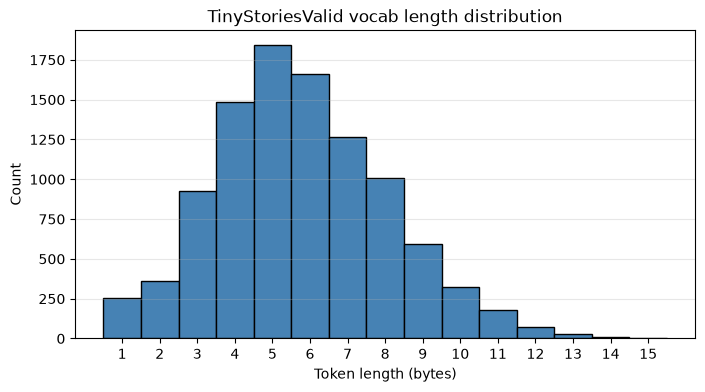

In [2]:
lengths = [len(token) for token in vocab.values()]
counts = Counter(lengths)

print(f"min={min(lengths)}, max={max(lengths)}, mean={sum(lengths) / len(lengths):.2f}")
print(dict(sorted(counts.items())))

fig, ax = plt.subplots(figsize=(8, 4))
bins = range(min(lengths), max(lengths) + 2)
ax.hist(lengths, bins=bins, align="left", edgecolor="black", color="steelblue")
ax.set_xticks(list(range(min(lengths), max(lengths) + 1)))
ax.set_xlabel("Token length (bytes)")
ax.set_ylabel("Count")
ax.set_title("TinyStoriesValid vocab length distribution")
ax.grid(axis="y", alpha=0.3)
plt.show()

In [3]:
# Longest tokens, by byte length
n_show = 20
longest = sorted(vocab.items(), key=lambda kv: (len(kv[1]), kv[1]), reverse=True)

print(f"Showing top {n_show} of {len(vocab):,} tokens\n")
print(f"{'id':>5}  {'bytes':>5}  token")
print("-" * 50)
for token_id, token in longest[:n_show]:
    try:
        decoded = token.decode("utf-8")
    except UnicodeDecodeError:
        decoded = token
    print(f"{token_id:5d}  {len(token):5d}  {decoded!r}")


Showing top 20 of 10,000 tokens

   id  bytes  token
--------------------------------------------------
 7426     15  ' accomplishment'
 5236     14  ' understanding'
 2954     14  ' uncomfortable'
 5997     14  ' neighbourhood'
 7897     14  ' encouragement'
 7051     14  ' determination'
 3675     14  ' compassionate'
 6351     14  ' Unfortunately'
 6310     13  'Unfortunately'
 9999     13  '<|endoftext|>'
 4479     13  ' veterinarian'
 8597     13  ' thundercloud'
 6909     13  ' surroundings'
 9392     13  ' successfully'
 4447     13  ' strawberries'
 9986     13  ' satisfaction'
 3827     13  ' refrigerator'
 9014     13  ' particularly'
 5676     13  ' neighborhood'
 9045     13  ' intelligence'


In [ ]:
# 5 example tokens for each byte length
from collections import defaultdict

def decode_token(token: bytes):
    try:
        return token.decode("utf-8")
    except UnicodeDecodeError:
        return token

by_length = defaultdict(list)
for token_id, token in vocab.items():
    by_length[len(token)].append((token_id, token))

for length in sorted(by_length):
    examples = by_length[length][:5]
    decoded = [repr(decode_token(token)) for _, token in examples]
    print(f"{length:2d} bytes ({len(by_length[length]):4d} tokens):  {', '.join(decoded)}")
